In [3]:
from pathlib import Path
import json
import numpy as np

dataset_path = Path("../robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training.npz")
artifact_path = Path("../outputs/map_balanced_pooled/BarClean/method_seed_000/learned_constraints.json")
with np.load(dataset_path, allow_pickle=False) as a:
    features = np.asarray(a["features"], float)
    names = [str(x) for x in a["feature_names"].tolist()]
    bounds = np.asarray(a["coarse_bounds_indices"], int)
artifact = json.loads(artifact_path.read_text())
print({"samples": len(features), "demos": len(bounds), "feature_names": names, "finite": bool(np.isfinite(features).all())})
pairs = artifact["feature_stage_modes"]
print("learned stage 2 modes:", {x["feature_name"]: (x["mode"], x.get("value"), x.get("mode_scores")) for x in pairs if x["stage"] == 1})

all_stats = {}
for stage_idx in (1, 2):
    print(f"\nSTAGE {stage_idx + 1} (1-based)")
    for feature_name in ("table_dist", "lateral_offset"):
        feat_idx = names.index(feature_name)
        feature_rows = []
        print(f"  {feature_name}")
        for demo_idx, row in enumerate(bounds):
            lo, hi = row[stage_idx], row[stage_idx + 1]
            x = features[lo:hi, feat_idx]
            edge = min(5, max(1, len(x)//4))
            slope = np.polyfit(np.arange(len(x)), x, 1)[0] if len(x) > 1 else np.nan
            vals = (x.mean(), x.std(), np.quantile(x, .05), np.median(x), np.quantile(x, .95), x[:edge].mean(), x[-edge:].mean(), slope)
            feature_rows.append(vals)
            print(f"    d{demo_idx}: n={len(x):2d} mean={vals[0]: .5f} std={vals[1]:.5f} q05/50/95=({vals[2]:.5f},{vals[3]:.5f},{vals[4]:.5f}) edge=({vals[5]:.5f}->{vals[6]:.5f}) slope={vals[7]:+.6f}")
        arr = np.asarray(feature_rows)
        all_stats[(stage_idx, feature_name)] = arr
        print(f"    pooled demo means=[{arr[:,0].min():.5f},{arr[:,0].max():.5f}], mean within-std={arr[:,1].mean():.5f}, edge mean={arr[:,5].mean():.5f}->{arr[:,6].mean():.5f}, max |slope|={np.abs(arr[:,7]).max():.6f}")

{'samples': 877, 'demos': 7, 'feature_names': ['obs_dist', 'table_dist', 'lateral_offset', 'tool_pitch', 'tool_roll', 'motion_axis_err', 'speed', 'angular_speed', 'axial_offset', 'tool_yaw'], 'finite': True}
learned stage 2 modes: {'obs_dist': ('inactive', None, {'inactive': 0.8229063056770353, 'target_value': 2.7103379441916456e-51, 'lower_bound': 0.10034044899043561, 'upper_bound': 0.076753245332529}), 'table_dist': ('lower_bound', 0.09333154943780486, {'inactive': 6.811928530538164e-06, 'target_value': 2.800581054906353e-07, 'lower_bound': 0.9999929079976484, 'upper_bound': 1.5715644196983403e-11}), 'lateral_offset': ('lower_bound', -0.004012146549177954, {'inactive': 0.20256729891123929, 'target_value': 0.04609902538925939, 'lower_bound': 0.7513185410745277, 'upper_bound': 1.513462497373162e-05}), 'axial_offset': ('inactive', None, {'inactive': 0.8814665715137662, 'target_value': 5.922185478789731e-23, 'lower_bound': 0.022327443262010752, 'upper_bound': 0.09620598522422306}), 'tool

In [4]:
def describe(x):
    x = np.asarray(x, float)
    mu, sd = x.mean(), x.std()
    skew = np.mean(((x - mu) / max(sd, 1e-12)) ** 3)
    return {"n": len(x), "mean": mu, "std": sd, "q05": np.quantile(x,.05), "q50": np.median(x), "q95": np.quantile(x,.95), "skew": skew}

print("Stage 2 sensitivity (1-based)")
for feature_name in ("table_dist", "lateral_offset"):
    feat_idx = names.index(feature_name)
    print("\n", feature_name)
    for label, demo_ids, trim in [
        ("all", range(7), 0),
        ("exclude_demo2", [0,1,3,4,5,6], 0),
        ("trim_first5_all", range(7), 5),
        ("trim_first10_all", range(7), 10),
    ]:
        chunks = []
        for demo_idx in demo_ids:
            lo, hi = bounds[demo_idx,1], bounds[demo_idx,2]
            start = min(lo + trim, hi - 1)
            chunks.append(features[start:hi, feat_idx])
        print(label, {k: round(v, 6) if isinstance(v, float) else v for k,v in describe(np.concatenate(chunks)).items()})

d = 2
lo, hi = bounds[d,1], bounds[d,2]
cols = [names.index(x) for x in ("table_dist", "lateral_offset", "axial_offset", "speed")]
print("\ndemo2 stage2 first 18 samples")
print("i table_dist lateral axial speed")
for i, vals in enumerate(features[lo:min(lo+18,hi), cols]):
    print(f"{i:2d} {vals[0]:.5f} {vals[1]:.5f} {vals[2]:.5f} {vals[3]:.5f}")

Stage 2 sensitivity (1-based)

 table_dist
all {'n': 218, 'mean': np.float64(0.100704), 'std': np.float64(0.020025), 'q05': np.float64(0.093313), 'q50': np.float64(0.095604), 'q95': np.float64(0.134573), 'skew': np.float64(4.241762)}
exclude_demo2 {'n': 175, 'mean': np.float64(0.095524), 'std': np.float64(0.001729), 'q05': np.float64(0.093221), 'q50': np.float64(0.09538), 'q95': np.float64(0.098418), 'skew': np.float64(1.642439)}
trim_first5_all {'n': 183, 'mean': np.float64(0.09861), 'std': np.float64(0.013351), 'q05': np.float64(0.093234), 'q50': np.float64(0.095536), 'q95': np.float64(0.111873), 'skew': np.float64(4.714102)}
trim_first10_all {'n': 148, 'mean': np.float64(0.096883), 'std': np.float64(0.0065), 'q05': np.float64(0.093212), 'q50': np.float64(0.095545), 'q95': np.float64(0.105748), 'skew': np.float64(4.591244)}

 lateral_offset
all {'n': 218, 'mean': np.float64(0.01229), 'std': np.float64(0.015508), 'q05': np.float64(-0.00154), 'q50': np.float64(0.00963), 'q95': np.float

In [5]:
source_path = Path("../robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training.npz")
destination_path = Path("../robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training_demo2_cutfix.npz")
if destination_path.exists():
    raise FileExistsError(f"Refusing to overwrite existing dataset: {destination_path}")

with np.load(source_path, allow_pickle=False) as archive:
    payload = {key: np.asarray(archive[key]).copy() for key in archive.files}

fixed_bounds = np.asarray(payload["coarse_bounds_indices"], dtype=np.int64).copy()
demo_index = 2
demo_begin = int(fixed_bounds[demo_index, 0])
old_local_cut = int(fixed_bounds[demo_index, 1] - demo_begin)
new_local_cut = 39
assert old_local_cut == 22, (old_local_cut, fixed_bounds[demo_index].tolist())
new_global_cut = demo_begin + new_local_cut
assert fixed_bounds[demo_index, 0] < new_global_cut < fixed_bounds[demo_index, 2]
fixed_bounds[demo_index, 1] = new_global_cut
assert np.all(np.diff(fixed_bounds, axis=1) > 0)
payload["coarse_bounds_indices"] = fixed_bounds

labels = np.asarray(payload["coarse_stage_labels"], dtype=np.int64).copy()
row = fixed_bounds[demo_index]
labels[row[0]:row[-1]] = np.repeat(np.arange(5, dtype=np.int64), np.diff(row))
payload["coarse_stage_labels"] = labels

feature_names = [str(x) for x in payload["feature_names"].tolist()]
feature_matrix = np.asarray(payload["features"], dtype=float)
definition_path = Path("../robot/stage_cons_iiwa14/ros_ws/src/stage_constraint_planner/config/bar_clean_true.json")
definition = json.loads(definition_path.read_text())
axial_reference = float(definition["bar_axial_offset_reference"])
task_xyz_at_cut = np.asarray([
    feature_matrix[new_global_cut, feature_names.index("axial_offset")] + axial_reference,
    feature_matrix[new_global_cut, feature_names.index("lateral_offset")],
    feature_matrix[new_global_cut, feature_names.index("table_dist")],
])
if "boundary_task_xyz_m" in payload:
    boundary_xyz = np.asarray(payload["boundary_task_xyz_m"], dtype=float).copy()
    boundary_xyz[demo_index, 0] = task_xyz_at_cut
    payload["boundary_task_xyz_m"] = boundary_xyz

payload["cutpoint_annotation_kind"] = np.asarray("5hz_task_motion_direction_change_points_with_manual_demo2_stage2_start_fix")
payload["cutpoint_evaluation_role"] = np.asarray("motion_phase_reference")
payload["manual_cutpoint_adjustments_json"] = np.asarray(json.dumps({
    "demo_index": demo_index,
    "boundary": "stage_1_to_2",
    "old_local_index": old_local_cut,
    "new_local_index": new_local_cut,
    "delta_samples": new_local_cut - old_local_cut,
    "sampling_hz": float(np.asarray(payload["downsample_hz"]).item()),
    "reason": "remove descent and lateral-alignment transient from stage 2",
}, sort_keys=True))

destination_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(destination_path, **payload)
print({
    "output": str(destination_path.resolve()),
    "demo2_old_bounds_local": (fixed_bounds[demo_index] - demo_begin).tolist(),
    "old_first_cut": old_local_cut,
    "new_first_cut": new_local_cut,
    "new_stage_lengths": np.diff(fixed_bounds[demo_index]).tolist(),
    "task_xyz_at_new_cut": task_xyz_at_cut.tolist(),
})

{'output': '/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training_demo2_cutfix.npz', 'demo2_old_bounds_local': [0, 39, 65, 79, 95, 114], 'old_first_cut': 22, 'new_first_cut': 39, 'new_stage_lengths': [39, 26, 14, 16, 19], 'task_xyz_at_new_cut': [-0.13147407917021223, 0.01074701341005486, 0.09650508788101178]}


In [6]:
import sys
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from envs.BarClean import load_BarClean

bundle = load_BarClean(
    processed_demo_path=destination_path.resolve(),
    n_demos=7,
    source_demo_ids=[0, 1, 2, 3, 4, 5, 6],
)
with np.load(source_path, allow_pickle=False) as old_a, np.load(destination_path, allow_pickle=False) as new_a:
    old_bounds_check = np.asarray(old_a["coarse_bounds_indices"], int)
    new_bounds_check = np.asarray(new_a["coarse_bounds_indices"], int)
    changed_entries = np.argwhere(old_bounds_check != new_bounds_check).tolist()
    arrays_unchanged = {
        key: bool(np.array_equal(old_a[key], new_a[key]))
        for key in ("trajectory", "features", "timestamps", "demo_id", "demo_bar_poses", "demo_obstacle_poses")
    }
    labels_match_bounds = all(
        np.array_equal(
            np.asarray(new_a["coarse_stage_labels"])[row[0]:row[-1]],
            np.repeat(np.arange(5), np.diff(row)),
        )
        for row in new_bounds_check
    )

demo2_stage2 = np.asarray(bundle.features[2])[
    int(bundle.true_cutpoints[2][0]):int(bundle.true_cutpoints[2][1])
]
name_to_col = {spec["name"]: int(spec["column_idx"]) for spec in bundle.feature_schema}
print({
    "loaded_demo_count": len(bundle.demos),
    "true_cutpoints": [np.asarray(x, int).tolist() for x in bundle.true_cutpoints],
    "changed_bound_entries": changed_entries,
    "unchanged_payload_arrays": arrays_unchanged,
    "labels_match_bounds": labels_match_bounds,
    "demo2_stage2_table_dist_mean_std": [
        float(demo2_stage2[:, name_to_col["table_dist"]].mean()),
        float(demo2_stage2[:, name_to_col["table_dist"]].std()),
    ],
    "demo2_stage2_lateral_mean_std": [
        float(demo2_stage2[:, name_to_col["lateral_offset"]].mean()),
        float(demo2_stage2[:, name_to_col["lateral_offset"]].std()),
    ],
    "finite": bool(all(np.isfinite(x).all() for x in bundle.features)),
})

{'loaded_demo_count': 7, 'true_cutpoints': [[42, 75, 92, 105], [35, 67, 85, 96], [39, 65, 79, 95], [41, 69, 84, 95], [37, 66, 75, 91], [49, 75, 88, 102], [40, 67, 81, 100]], 'changed_bound_entries': [[2, 1]], 'unchanged_payload_arrays': {'trajectory': True, 'features': True, 'timestamps': True, 'demo_id': True, 'demo_bar_poses': True, 'demo_obstacle_poses': True}, 'labels_match_bounds': True, 'demo2_stage2_table_dist_mean_std': [0.09716555669502294, 0.002892700316177285], 'demo2_stage2_lateral_mean_std': [0.015554001879805364, 0.0031541747635826867], 'finite': True}


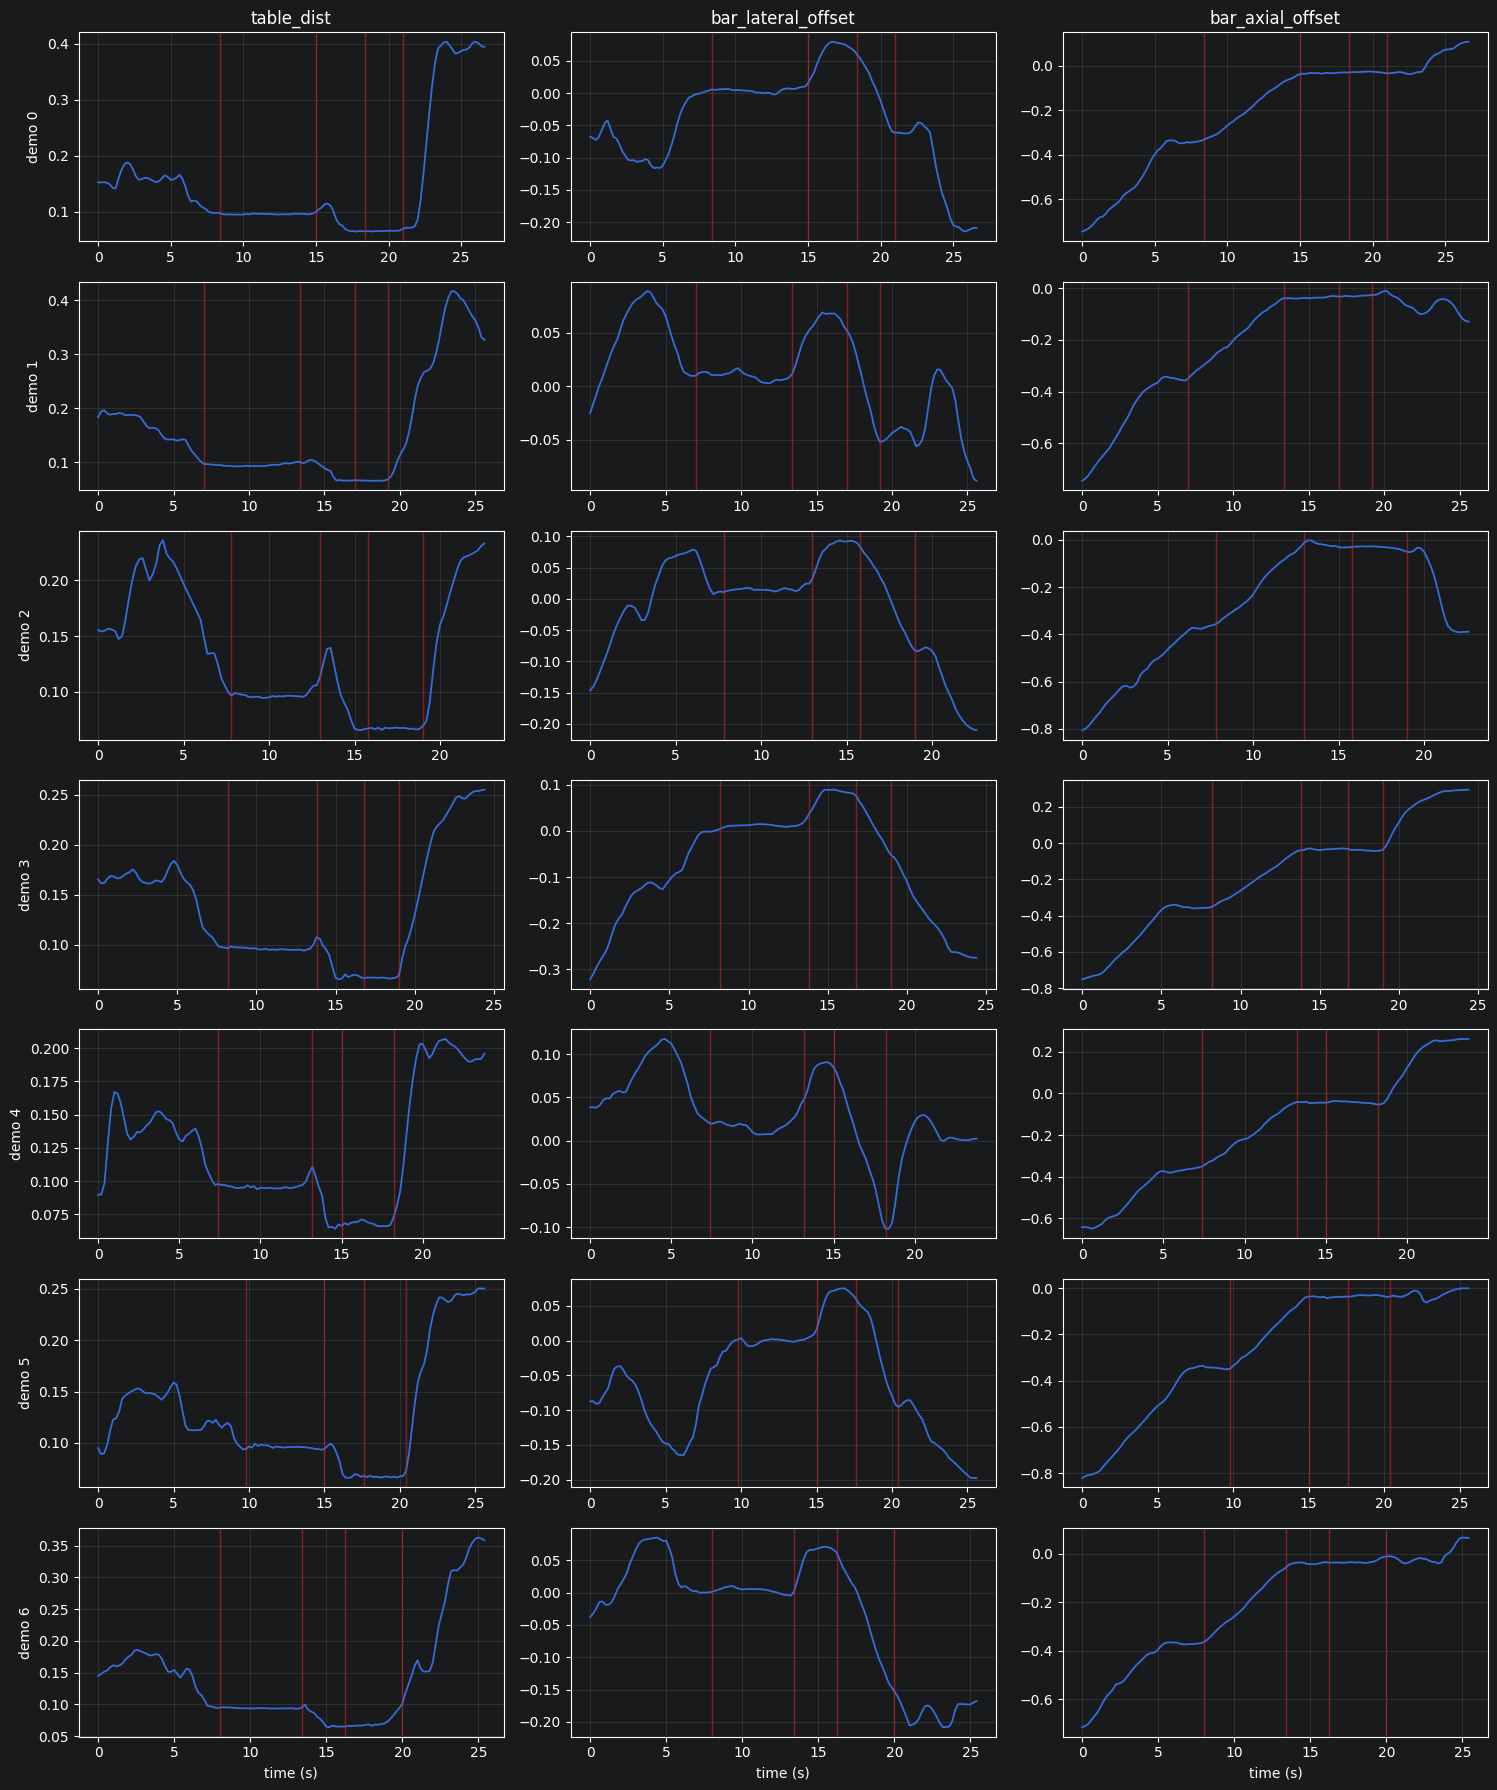

In [7]:
import matplotlib.pyplot as plt

with np.load(dataset_path, allow_pickle=False) as a:
    features_now = np.asarray(a["features"], float)
    names_now = [str(x) for x in a["feature_names"].tolist()]
    bounds_now = np.asarray(a["coarse_bounds_indices"], int)

fig, axes = plt.subplots(7, 3, figsize=(15, 18), sharex=False)
feature_triplet = ["table_dist", "lateral_offset", "axial_offset"]
for demo_idx, row in enumerate(bounds_now):
    begin, end = int(row[0]), int(row[-1])
    local_cuts = row[1:-1] - begin
    t = np.arange(end - begin) / 5.0
    for col, feature_name in enumerate(feature_triplet):
        ax = axes[demo_idx, col]
        ax.plot(t, features_now[begin:end, names_now.index(feature_name)], lw=1.3)
        for cut in local_cuts:
            ax.axvline(cut / 5.0, color="tab:red", alpha=.55, lw=1)
        ax.grid(alpha=.2)
        if demo_idx == 0:
            ax.set_title(feature_name)
        if col == 0:
            ax.set_ylabel(f"demo {demo_idx}")
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
axes[-1, 2].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

In [8]:
def contiguous_runs(mask):
    padded = np.r_[False, np.asarray(mask, bool), False]
    edges = np.flatnonzero(padded[1:] != padded[:-1])
    return [(int(a), int(b)) for a, b in edges.reshape(-1, 2)]

def longest_run(mask, min_len=4):
    runs = [(a,b) for a,b in contiguous_runs(mask) if b-a >= min_len]
    return max(runs, key=lambda ab: ab[1]-ab[0]) if runs else None

table_col = names_now.index("table_dist")
lat_col = names_now.index("lateral_offset")
ax_col = names_now.index("axial_offset")
candidate_rows = []
for demo_idx, row in enumerate(bounds_now):
    begin, end = int(row[0]), int(row[-1])
    x = features_now[begin:end]
    table = x[:, table_col]
    lateral = x[:, lat_col]
    axial = x[:, ax_col]
    high_mask = (table >= 0.090) & (table <= 0.105) & (np.abs(lateral) <= 0.035)
    low_mask = (table >= 0.060) & (table <= 0.076)
    high = longest_run(high_mask, min_len=8)
    low = longest_run(low_mask, min_len=8)
    current = (row - begin).tolist()
    candidate_rows.append((high, low))
    print(f"d{demo_idx}: current={current}; high={high}; low={low}; lengths={(high[1]-high[0], low[1]-low[0]) if high and low else None}")
    if high and low:
        print(f"    high edges table=({table[high[0]]:.4f},{table[high[1]-1]:.4f}) lat=({lateral[high[0]]:.4f},{lateral[high[1]-1]:.4f}) axial=({axial[high[0]]:.4f},{axial[high[1]-1]:.4f})")
        print(f"    low  edges table=({table[low[0]]:.4f},{table[low[1]-1]:.4f}) lat=({lateral[low[0]]:.4f},{lateral[low[1]-1]:.4f}) axial=({axial[low[0]]:.4f},{axial[low[1]-1]:.4f})")

d0: current=[0, 42, 75, 92, 105, 134]; high=(38, 77); low=(84, 110); lengths=(39, 26)
    high edges table=(0.1001,0.1046) lat=(-0.0004,0.0238) axial=(-0.3445,-0.0354)
    low  edges table=(0.0758,0.0742) lat=(0.0794,-0.0626) axial=(-0.0309,-0.0283)
d1: current=[0, 35, 67, 85, 96, 129]; high=(34, 70); low=(78, 98); lengths=(36, 20)
    high edges table=(0.1018,0.1012) lat=(0.0097,0.0288) axial=(-0.3574,-0.0387)
    low  edges table=(0.0732,0.0742) lat=(0.0675,-0.0513) axial=(-0.0371,-0.0262)
d2: current=[0, 39, 65, 79, 95, 114]; high=(38, 63); low=(74, 97); lengths=(25, 23)
    high edges table=(0.1002,0.1019) lat=(0.0120,0.0199) axial=(-0.3614,-0.0554)
    low  edges table=(0.0747,0.0737) lat=(0.0919,-0.0837) axial=(-0.0255,-0.0517)
d3: current=[0, 41, 69, 84, 95, 123]; high=(37, 69); low=(75, 96); lengths=(32, 21)
    high edges table=(0.1030,0.1002) lat=(-0.0016,0.0235) axial=(-0.3589,-0.0429)
    low  edges table=(0.0671,0.0693) lat=(0.0886,-0.0525) axial=(-0.0375,-0.0366)
d4: curr

In [9]:
print("Wider stable-band candidates")
wide_candidates = []
for demo_idx, row in enumerate(bounds_now):
    begin, end = int(row[0]), int(row[-1])
    x = features_now[begin:end]
    table = x[:, table_col]
    lateral = x[:, lat_col]
    axial = x[:, ax_col]
    high = longest_run((table >= 0.088) & (table <= 0.108) & (np.abs(lateral) <= 0.040), min_len=8)
    low = longest_run((table >= 0.058) & (table <= 0.082), min_len=8)
    wide_candidates.append((high, low))
    print(f"d{demo_idx}: high={high}, low={low}, current={(row-begin).tolist()}")

Wider stable-band candidates
d0: high=(36, 78), low=(83, 110), current=[0, 42, 75, 92, 105, 134]
d1: high=(33, 71), low=(78, 98), current=[0, 35, 67, 85, 96, 129]
d2: high=(37, 65), low=(74, 97), current=[0, 39, 65, 79, 95, 114]
d3: high=(36, 70), low=(74, 96), current=[0, 41, 69, 84, 95, 123]
d4: high=(34, 65), low=(70, 93), current=[0, 37, 66, 75, 91, 120]
d5: high=(45, 77), low=(80, 103), current=[0, 49, 75, 88, 102, 129]
d6: high=(35, 70), low=(72, 97), current=[0, 40, 67, 81, 100, 128]


In [10]:
proposed_local_bounds = np.asarray([
    [0, 38, 77, 84, 110, 134],
    [0, 34, 70, 78, 98, 129],
    [0, 38, 63, 74, 97, 114],
    [0, 37, 69, 75, 96, 123],
    [0, 35, 65, 70, 92, 120],
    [0, 45, 77, 81, 103, 129],
    [0, 36, 70, 74, 96, 128],
], dtype=np.int64)

print("Proposed local bounds and stable-stage stats")
for demo_idx, local in enumerate(proposed_local_bounds):
    begin = int(bounds_now[demo_idx, 0])
    assert int(local[-1]) == int(bounds_now[demo_idx, -1] - begin)
    high = features_now[begin+local[1]:begin+local[2]]
    low = features_now[begin+local[3]:begin+local[4]]
    print(
        f"d{demo_idx}: {local.tolist()} lengths={np.diff(local).tolist()} | "
        f"high table={high[:,table_col].mean():.5f}±{high[:,table_col].std():.5f}, "
        f"lat={high[:,lat_col].mean():.5f}±{high[:,lat_col].std():.5f} | "
        f"low table={low[:,table_col].mean():.5f}±{low[:,table_col].std():.5f}, "
        f"axial={low[:,ax_col].mean():.5f}±{low[:,ax_col].std():.5f}"
    )

high_all = np.concatenate([
    features_now[int(row[0])+local[1]:int(row[0])+local[2]]
    for row, local in zip(bounds_now, proposed_local_bounds)
])
low_all = np.concatenate([
    features_now[int(row[0])+local[3]:int(row[0])+local[4]]
    for row, local in zip(bounds_now, proposed_local_bounds)
])
print("pooled high:", {
    "table_mean_std": (float(high_all[:,table_col].mean()), float(high_all[:,table_col].std())),
    "lateral_mean_std": (float(high_all[:,lat_col].mean()), float(high_all[:,lat_col].std())),
})
print("pooled low:", {
    "table_mean_std": (float(low_all[:,table_col].mean()), float(low_all[:,table_col].std())),
    "axial_mean_std": (float(low_all[:,ax_col].mean()), float(low_all[:,ax_col].std())),
})

Proposed local bounds and stable-stage stats
d0: [0, 38, 77, 84, 110, 134] lengths=[38, 39, 7, 26, 24] | high table=0.09657±0.00179, lat=0.00476±0.00463 | low table=0.06743±0.00305, axial=-0.02952±0.00235
d1: [0, 34, 70, 78, 98, 129] lengths=[34, 36, 8, 20, 31] | high table=0.09576±0.00273, lat=0.01044±0.00497 | low table=0.06729±0.00220, axial=-0.03142±0.00304
d2: [0, 38, 63, 74, 97, 114] lengths=[38, 25, 11, 23, 17] | high table=0.09660±0.00168, lat=0.01471±0.00201 | low table=0.06776±0.00215, axial=-0.03308±0.00705
d3: [0, 37, 69, 75, 96, 123] lengths=[37, 32, 6, 21, 27] | high table=0.09642±0.00176, lat=0.01028±0.00519 | low table=0.06753±0.00131, axial=-0.03604±0.00423
d4: [0, 35, 65, 70, 92, 120] lengths=[35, 30, 5, 22, 28] | high table=0.09582±0.00157, lat=0.01696±0.00655 | low table=0.06785±0.00220, axial=-0.04340±0.00436
d5: [0, 45, 77, 81, 103, 129] lengths=[45, 32, 4, 22, 26] | high table=0.09635±0.00212, lat=0.00072±0.00765 | low table=0.06770±0.00146, axial=-0.03478±0.0038

In [11]:
import os

dataset_path = Path("../robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training.npz")
with np.load(dataset_path, allow_pickle=False) as archive:
    payload = {key: np.asarray(archive[key]).copy() for key in archive.files}

new_global_bounds = np.asarray([
    local + int(bounds_now[i, 0])
    for i, local in enumerate(proposed_local_bounds)
], dtype=np.int64)
payload["coarse_bounds_indices"] = new_global_bounds

new_labels = np.asarray(payload["coarse_stage_labels"], dtype=np.int64).copy()
for row in new_global_bounds:
    new_labels[row[0]:row[-1]] = np.repeat(np.arange(5, dtype=np.int64), np.diff(row))
payload["coarse_stage_labels"] = new_labels

feature_matrix = np.asarray(payload["features"], dtype=float)
feature_names = [str(x) for x in payload["feature_names"].tolist()]
definition = json.loads(Path("../robot/stage_cons_iiwa14/ros_ws/src/stage_constraint_planner/config/bar_clean_true.json").read_text())
axial_reference = float(definition["bar_axial_offset_reference"])
boundary_xyz = np.empty((len(new_global_bounds), 4, 3), dtype=float)
for demo_idx, row in enumerate(new_global_bounds):
    for boundary_idx, global_index in enumerate(row[1:-1]):
        boundary_xyz[demo_idx, boundary_idx] = [
            feature_matrix[global_index, feature_names.index("axial_offset")] + axial_reference,
            feature_matrix[global_index, feature_names.index("lateral_offset")],
            feature_matrix[global_index, feature_names.index("table_dist")],
        ]
payload["boundary_task_xyz_m"] = boundary_xyz
payload["cutpoint_annotation_kind"] = np.asarray("5hz_table_stability_with_bar_offset_reference")
payload["cutpoint_evaluation_role"] = np.asarray("motion_phase_reference")
payload.pop("manual_cutpoint_adjustments_json", None)

temporary_path = dataset_path.with_name(dataset_path.stem + ".rewrite_tmp.npz")
np.savez_compressed(temporary_path, **payload)
os.replace(temporary_path, dataset_path)
print("overwritten:", dataset_path.resolve())
print("true cutpoints:", [row[1:-1].tolist() for row in proposed_local_bounds])
print("stage lengths:", [np.diff(row).tolist() for row in proposed_local_bounds])

overwritten: /home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training.npz
true cutpoints: [[38, 77, 84, 110], [34, 70, 78, 98], [38, 63, 74, 97], [37, 69, 75, 96], [35, 65, 70, 92], [45, 77, 81, 103], [36, 70, 74, 96]]
stage lengths: [[38, 39, 7, 26, 24], [34, 36, 8, 20, 31], [38, 25, 11, 23, 17], [37, 32, 6, 21, 27], [35, 30, 5, 22, 28], [45, 32, 4, 22, 26], [36, 34, 4, 22, 32]]


In [12]:
bundle = load_BarClean(
    processed_demo_path=dataset_path.resolve(),
    n_demos=7,
    source_demo_ids=[0, 1, 2, 3, 4, 5, 6],
)
with np.load(dataset_path, allow_pickle=False) as checked:
    checked_bounds = np.asarray(checked["coarse_bounds_indices"], int)
    checked_labels = np.asarray(checked["coarse_stage_labels"], int)
    labels_ok = all(
        np.array_equal(
            checked_labels[row[0]:row[-1]],
            np.repeat(np.arange(5), np.diff(row)),
        )
        for row in checked_bounds
    )
print({
    "loader_ok": len(bundle.demos) == 7,
    "true_cutpoints": [np.asarray(x, int).tolist() for x in bundle.true_cutpoints],
    "labels_ok": labels_ok,
    "all_finite": bool(all(np.isfinite(x).all() for x in bundle.features)),
    "minimum_stage_length": int(min(np.diff(row).min() for row in checked_bounds)),
    "annotation_kind": bundle.meta["cutpoint_annotation_kind"],
})

{'loader_ok': True, 'true_cutpoints': [[38, 77, 84, 110], [34, 70, 78, 98], [38, 63, 74, 97], [37, 69, 75, 96], [35, 65, 70, 92], [45, 77, 81, 103], [36, 70, 74, 96]], 'labels_ok': True, 'all_finite': True, 'minimum_stage_length': 4, 'annotation_kind': '5hz_table_stability_with_bar_offset_reference'}


In [13]:
current_artifact = json.loads(Path("../outputs/map_balanced_pooled/BarClean/method_seed_000/learned_constraints.json").read_text())
with np.load(dataset_path, allow_pickle=False) as a:
    f = np.asarray(a["features"], float)
    fn = [str(x) for x in a["feature_names"].tolist()]
    b = np.asarray(a["coarse_bounds_indices"], int)

truth = {"tool_pitch": np.pi/2, "tool_roll": 0.0}
scale_by_feature = {x["feature_name"]: float(x["scale"]) for x in current_artifact["feature_stage_modes"] if x["stage"] == 1}
print("MAP effective EQ sigma upper bounds (map_eq_sigma=0.1):", {
    name: {"rad": 0.1*scale_by_feature[name], "deg": np.rad2deg(0.1*scale_by_feature[name])}
    for name in truth
})

for stage_idx in (1, 3):
    print(f"\nSTAGE {stage_idx+1} (1-based)")
    for feature_name in ("tool_pitch", "tool_roll"):
        col = fn.index(feature_name)
        chunks = []
        means = []
        print(feature_name, "truth_deg=", np.rad2deg(truth[feature_name]))
        for demo_idx, row in enumerate(b):
            x = f[row[stage_idx]:row[stage_idx+1], col]
            chunks.append(x)
            means.append(x.mean())
            slope = np.polyfit(np.arange(len(x)), x, 1)[0] if len(x)>1 else 0.0
            print(
                f"  d{demo_idx}: mean={np.rad2deg(x.mean()):+.2f}°, "
                f"std={np.rad2deg(x.std()):.2f}°, "
                f"range=[{np.rad2deg(x.min()):+.2f},{np.rad2deg(x.max()):+.2f}]°, "
                f"slope={np.rad2deg(slope):+.3f}°/sample"
            )
        pooled = np.concatenate(chunks)
        print(
            f"  pooled: mean={np.rad2deg(pooled.mean()):+.2f}°, std={np.rad2deg(pooled.std()):.2f}°, "
            f"demo-mean spread={np.rad2deg(np.std(means)):.2f}°, "
            f"bias-to-truth={np.rad2deg(pooled.mean()-truth[feature_name]):+.2f}°"
        )
        match = next(x for x in current_artifact["feature_stage_modes"] if x["stage"]==stage_idx and x["feature_name"]==feature_name)
        print("  MAP:", {"mode": match["mode"], "scores": match["mode_scores"]})

MAP effective EQ sigma upper bounds (map_eq_sigma=0.1): {'tool_pitch': {'rad': 0.07699818090903335, 'deg': np.float64(4.411670796272399)}, 'tool_roll': {'rad': 0.0720173280632392, 'deg': np.float64(4.126288949832669)}}

STAGE 2 (1-based)
tool_pitch truth_deg= 90.0
  d0: mean=+90.76°, std=0.99°, range=[+88.54,+92.89]°, slope=-0.028°/sample
  d1: mean=+91.69°, std=2.66°, range=[+87.16,+96.78]°, slope=-0.239°/sample
  d2: mean=+91.45°, std=1.63°, range=[+88.78,+94.00]°, slope=+0.093°/sample
  d3: mean=+86.76°, std=1.82°, range=[+84.08,+89.36]°, slope=-0.179°/sample
  d4: mean=+88.74°, std=4.53°, range=[+82.96,+95.63]°, slope=-0.446°/sample
  d5: mean=+88.47°, std=1.49°, range=[+86.78,+92.18]°, slope=-0.147°/sample
  d6: mean=+84.95°, std=1.79°, range=[+82.38,+88.23]°, slope=-0.154°/sample
  pooled: mean=+88.97°, std=3.33°, demo-mean spread=2.33°, bias-to-truth=-1.03°
  MAP: {'mode': 'inactive', 'scores': {'inactive': 0.9736775637835802, 'target_value': 1.9191682882635486e-07, 'lower_bound